the part is demo of linear transformation for illuminant estimation<br>

try to find a patter between ALS information and illuminant color in RGB domain

In [1]:
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
from necessityFunc import *
import pandas as pd

In [2]:
arr_WPs = np.load('./data_WPs_NormalDataset.npy')
arr_ALSs = np.load('./data_ALSs_NormalDataset.npy')

arr_WPs = normalize(arr_WPs)
arr_ALSs = normalize(arr_ALSs)

determine the hyperparameter, `n_clusters` by Gap-Statistic 

In [3]:
arr_data = np.concatenate([arr_ALSs,arr_WPs],axis=1)

_,optimal_n = compute_gap_statistic(arr_data,max_k=100)
print(f"Optimal number of clusters based on gap statistic: {optimal_n}")

Optimal number of clusters based on gap statistic: 17


choose center data of K-Means for training $M$ for Linear Transformation

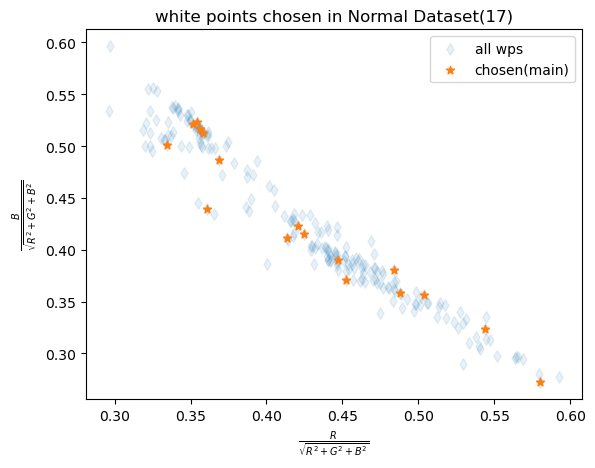

In [4]:
# choose centers of data
num_clusters = optimal_n
arr_WPschosen, lis_idx = data_chosen_KMeans(arr_data,num_clusters=num_clusters)

plt.figure()
plt.scatter(arr_WPs[:,0],arr_WPs[:,2],
            marker='d',label='all wps',alpha=.1)
plt.scatter(arr_WPs[lis_idx,0],arr_WPs[lis_idx,2],
            marker='*',label='chosen(main)')
plt.xlabel(r'$\frac{R}{\sqrt{R^2+G^2+B^2}}$')
plt.ylabel(r'$\frac{B}{\sqrt{R^2+G^2+B^2}}$')
plt.title('white points chosen in Normal Dataset'+'('+str(num_clusters)+')')
plt.legend()
plt.show()

using $WP = ALS \cdot M_{13\times3}$ for illuminat estimation

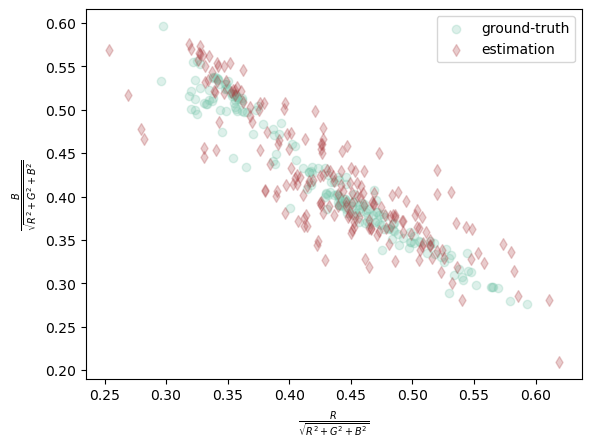

In [5]:
arr_WPschosen = arr_WPs[lis_idx,:] 
arr_ALSschosen = arr_ALSs[lis_idx,:]

MALS21x = np.matmul(np.linalg.pinv(arr_ALSschosen),arr_WPschosen)

# visualization for different results
lis_val = [item for item in np.arange(0,arr_WPs.shape[0]).tolist() if item not in lis_idx]
_,AEOALS = calculate_angular_error(arr_WPs[lis_val,:],arr_ALSs[lis_val,:]@MALS21x)

EstWPs = arr_ALSs[lis_val,:]@MALS21x

plt.figure()
plt.scatter(arr_WPs[lis_val,0],arr_WPs[lis_val,2],label='ground-truth',alpha=.25,color='#7bc7ad')
plt.scatter(EstWPs[:,0],EstWPs[:,2],label='estimation',alpha=.25,marker='d',color='#a9373b')
plt.legend()
plt.xlabel(r'$\frac{R}{\sqrt{R^2+G^2+B^2}}$')
plt.ylabel(r'$\frac{B}{\sqrt{R^2+G^2+B^2}}$')
plt.show()